# Follow-Up Module 2: Histogram Equalization and Specification
**Name:** I Nyoman Widiyasa Jayananda  
**Student ID:** F1D02410053  
**Group:** 14

## Introduction
This follow-up module dives deep into the mathematics of histogram-based image enhancement techniques. The core focus is on implementing **Histogram Equalization** and **Histogram Specification (Matching)**, computing Cumulative Distribution Functions (CDFs), building mapping transfer functions, and remapping pixel intensities entirely through manual matrix operations, without leaning on high-level, pre-built convenience wrappers for the core algorithms. The module also explores **chaining specifications sequentially** to study how applying one target distribution on top of another compounds and transforms the tonal character of an image.

## 1. Import Libraries & Setup

In [1]:
%matplotlib widget
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Ensure we reload if the script changes
sys.path.insert(0, '.')
ip = importlib.import_module('all-script-accelerated')
importlib.reload(ip)

%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 4)

[accelerated] 🚀 GPU: NVIDIA GeForce RTX 3050 Laptop GPU (4095 MB) | auto ≥256px
[accelerated] 🚀 GPU: NVIDIA GeForce RTX 3050 Laptop GPU (4095 MB) | auto ≥256px


**Why these libraries?**
- `cv2`: Reads and decodes the source image from disk into a NumPy array.
- `numpy`: Provides the foundational N-dimensional array structure all pixel manipulations operate on.
- `matplotlib.pyplot`: Renders images and pixel frequency histograms visually inside the notebook.
- `importlib`: Dynamically loads and hot-reloads the custom accelerated processing module (`all-script-accelerated.py`), which contains every manual implementation of the required algorithms. **Open that file to explore the underlying math!**

> **GPU Acceleration:** The custom module automatically detects and leverages an available GPU (NVIDIA GeForce RTX 3050 Laptop GPU, 4 GB) to accelerate operations on images ≥ 256 pixels in either dimension.

## 2. Load Image

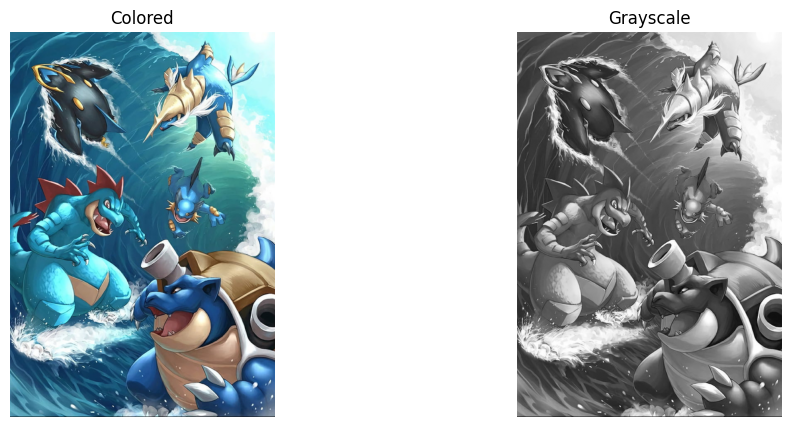

In [2]:
img_color = ip.Image_Ops.read('./water.jpg')
img_gray = ip.Image_Ops.to_grayscale(img_color)
ip.Image_Ops.show_pair(img_color, img_gray, "Colored", "Grayscale")

The source image (`water.jpg`) is a vivid, colorful piece of Pokémon artwork depicting an epic water-type battle scene featuring Blastoise, Gyarados, Feraligatr, Lapras, and others. Loading it in both its original color form and as a converted grayscale image establishes the baseline for all subsequent processing.

| Colored | Grayscale |
|---------|-----------|
| Full RGB channel data: rich blues, teals, and oranges | Single-channel luminance matrix; weighted intensity of each pixel |

Working in grayscale (a 2D matrix) is standard for histogram-based processing because it allows studying and manipulating a single frequency distribution rather than three separate ones.

## 3. Histogram Equalization

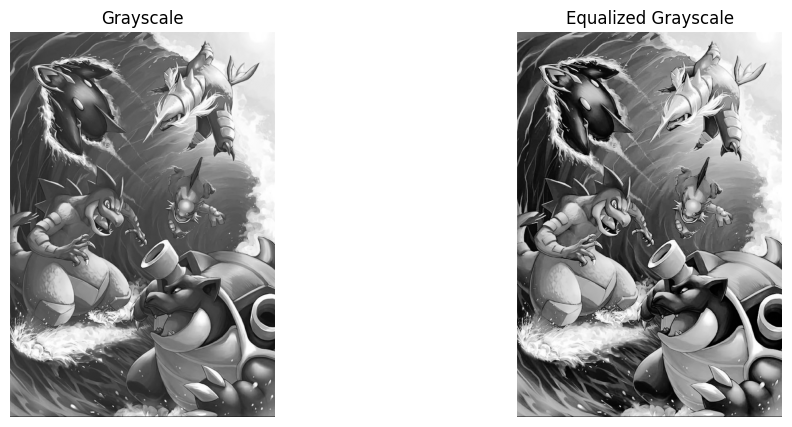

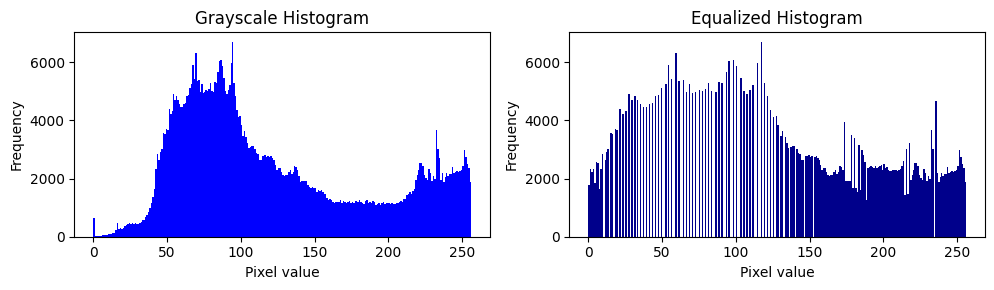

In [3]:
img_equalized = ip.Equalization.equalize(img_gray)
ip.Image_Ops.show_pair(img_gray, img_equalized, "Grayscale", "Equalized Grayscale")
ip.Histogram.show_multi(
    [img_gray, img_equalized], 
    titles=["Grayscale Histogram", "Equalized Histogram"],
    colors=["blue", "darkblue"]
)


Histogram Equalization automatically improves global contrast by redistributing pixel intensities so they span the full available dynamic range (0–255) as uniformly as possible.

**The algorithm, step by step:**
1. **Compute the frequency histogram**: count how many pixels fall on each intensity level (0–255).
2. **Build the CDF**: compute the running total of pixel counts from intensity 0 upward.
3. **Normalize the CDF**: scale it to the target output range [0, 255].
4. **Apply the mapping**: use the normalized CDF as a lookup table to remap each pixel's intensity.

**Visual result:** The equalized image shows noticeably better contrast in mid-tone and shadow regions. Details previously buried in the dark lower-left of the histogram become visible as those intensities are stretched outward.

| Grayscale Histogram | Equalized Histogram |
|---|---|
| Tall, narrow peaks clustered between ~50–130; heavy concentration in dark-to-mid-tone range | Wider distribution spanning ~0–255; the characteristic comb-like pattern is the "stretching" signature of CDF-based equalization |

The **comb effect** (evenly spaced gaps) is an expected mathematical artifact: equalization maps multiple source intensities to the same output value in regions with a steep CDF, leaving certain output bins empty while adjacent bins accumulate more counts.

## 4. Target Histograms for Specification

### 4.1 Loading Reference Distributions

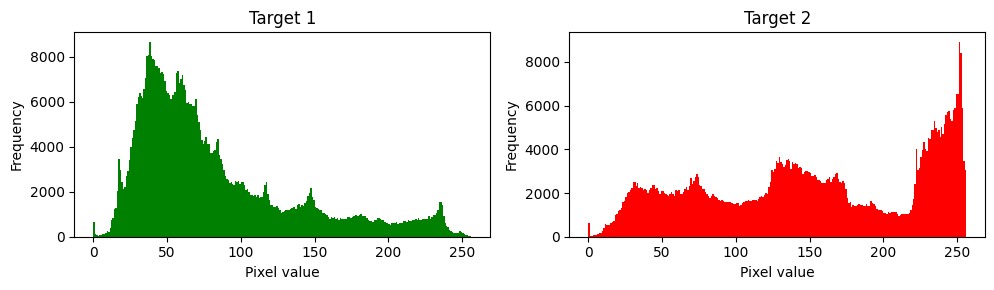

In [4]:
target1 = ip.TargetHistogram.load_csv("target 1.csv")
target2 = ip.TargetHistogram.load_csv("target 2.csv")

target1_img = ip.TargetHistogram.to_image(target1, shape=img_gray.shape)
target2_img = ip.TargetHistogram.to_image(target2, shape=img_gray.shape)

ip.Histogram.show_multi([target1_img, target2_img],
                        titles=["Target 1", "Target 2"],
                        colors=["green", "red"]
                        )

Histogram Specification (also called Histogram Matching) goes one step beyond equalization: instead of targeting a perfectly flat distribution, we aim for a **specific, arbitrary target distribution** defined by an external reference.

| Target | Color | Shape | Visual Character |
|--------|-------|-------|-----------------|
| **Target 1** | 🟢 Green | Strongly skewed toward low intensities (sharp peak near 40–50, long gradual tail) | Produces a darker, moodier result; shadows are deepened |
| **Target 2** | 🔴 Red | Broad, relatively flat, rising sharply toward high intensities (large peak near 255) | Produces a brighter, higher-key result; highlights are pulled out |

## 5. Histogram Specification (Matching)

### 5.1 The Core Algorithm
**Step by step:**
1. **Compute the CDF of the source image**: running frequency totals of the source.
2. **Compute the CDF of the target histogram**: running frequency totals of the desired distribution.
3. **Build the inverse CDF mapping**: for each source intensity, find the target intensity whose CDF value most closely matches. This creates a pixel-remapping lookup table.
4. **Remap every pixel**: apply the lookup table to push each pixel's intensity toward where it "should" fall in the target distribution.

### 5.2 Direct Specification: Source -> Target 1 & Target 2

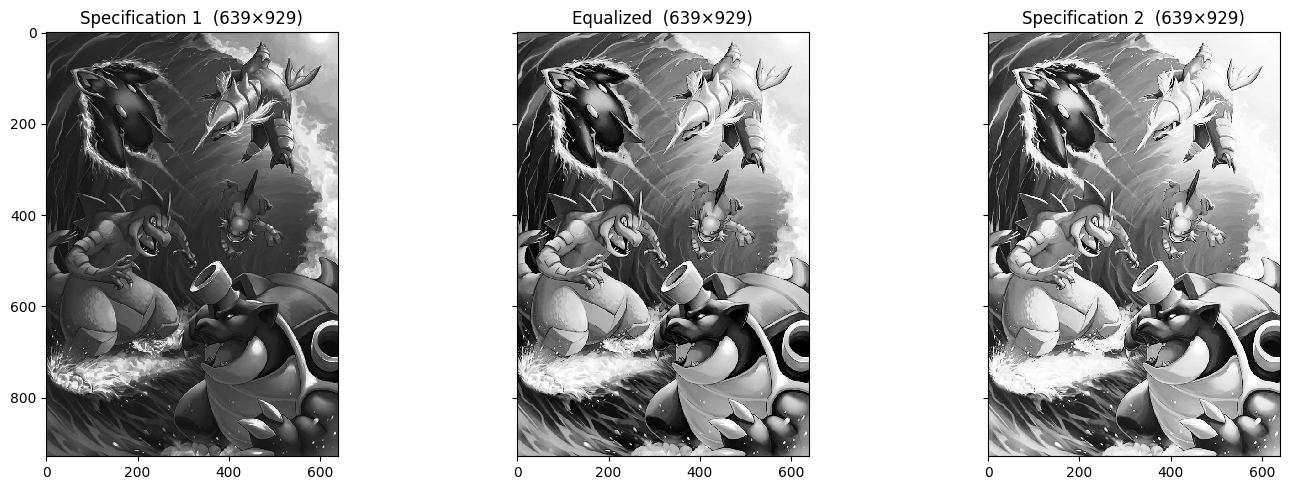

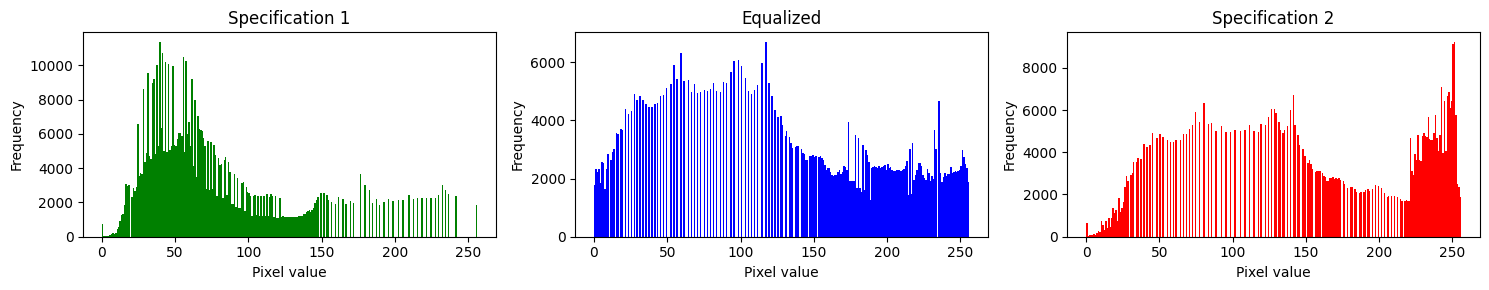

In [5]:
img_specified_1 = ip.Specialization.match(img_gray, target1_img)
img_specified_2 = ip.Specialization.match(img_gray, target2_img)


ip.Image_Ops.inspect_multi([img_specified_1, img_equalized, img_specified_2], 
                           titles=["Specification 1", "Equalized", "Specification 2"],
                           )
ip.Histogram.show_multi([img_specified_1, img_equalized, img_specified_2],
                        titles=["Specification 1", "Equalized", "Specification 2"],
                        colors=["green", "blue", "red"]
                        )

The equalized image is matched directly against each target, and the three results (Spec 1, Equalized baseline, Spec 2) are compared side by side at native 639×929 resolution alongside their histograms:

| Image | Histogram Shape | Visual Effect |
|-------|----------------|---------------|
| **Specification 1** | Dark green, heavy left skew (peak ~40–60) | Darker overall; shadow regions are richer; mid-tones are compressed |
| **Equalized** (baseline) | Blue, comb pattern spanning full range | Balanced contrast across the full range |
| **Specification 2** | Red, broad and flat, rising toward 255 | Brighter overall; highlights more prominent; water foam and shells more luminous |

## 6. Chained Specification

A key experiment in this module is **applying two specifications sequentially**, using the output of one as the input to the next. This tests how a second target distribution modifies a result that already has a shaped histogram.

### 6.1 Chain 1->2: Apply Target 1 then Target 2
- **Start:** `img_spec_1` already has a dark, left-skewed distribution matching Target 1.
- **Apply Target 2** on top: the pixels are redistributed again, but this time, pulling intensities toward the brighter, high-key Target 2 distribution.
- **Result (`Specification 1-2`):** The compressed dark tones from Spec 1 are spread back outward, producing a more even, relatively flat distribution similar to equalization, but not identical, since the intermediate Target 1 step biased the starting distribution differently than the original grayscale.

### 6.2 Chain 2->1: Apply Target 2 then Target 1
- **Start:** `img_spec_2` already has a broad, bright, high-key distribution matching Target 2.
- **Apply Target 1** on top: the pixels are now strongly remapped toward the dark, left-skewed Target 1.
- **Result (`Specification 2-1`):** The brightened highlights from Spec 2 are crushed back into the shadow zone. The final image is very dark and moody; darker even than a direct Target 1 specification from the original grayscale, because the intermediate Target 2 step stretched the range differently before Target 1 re-compressed it.

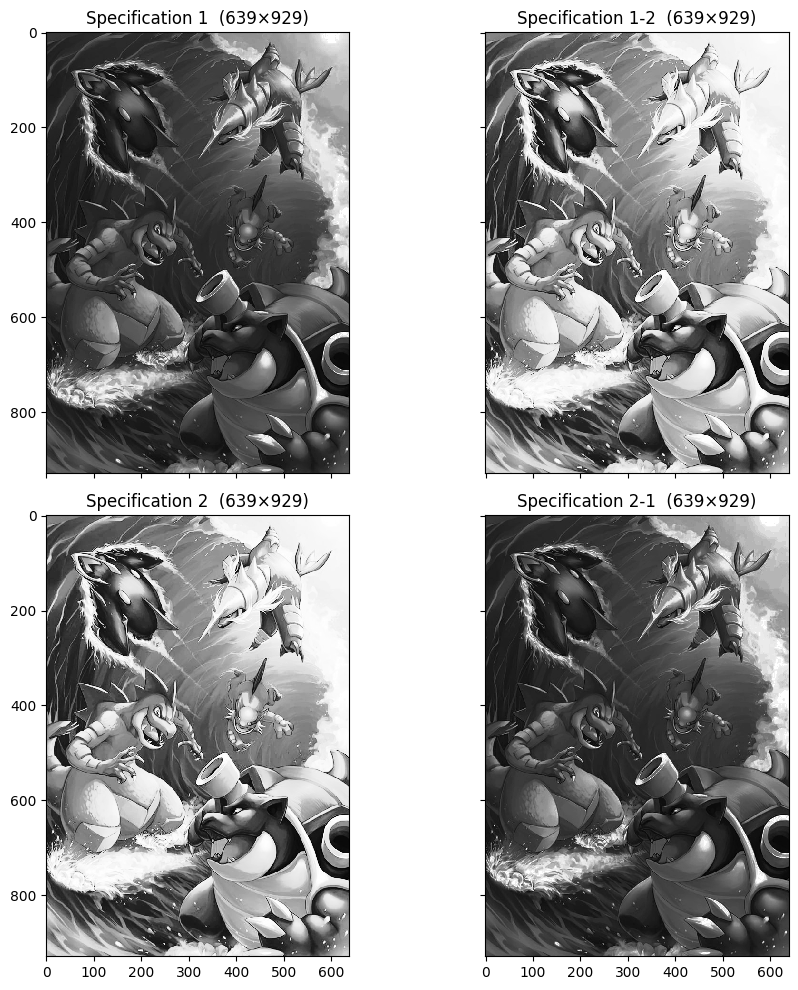

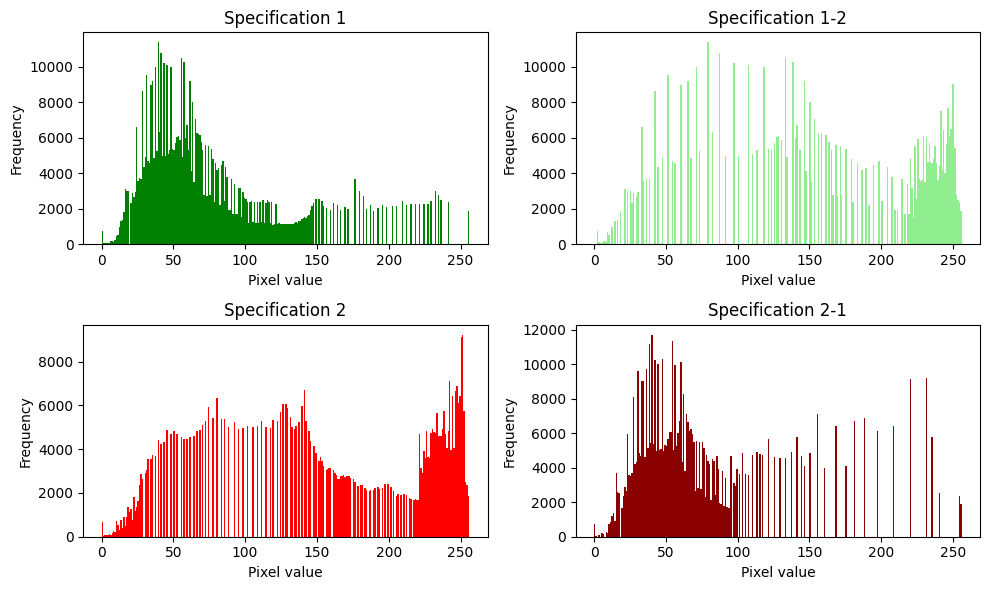

In [6]:
img_specified_1_2 = ip.Specialization.match(img_specified_1, img_specified_2)
img_specified_2_1 = ip.Specialization.match(img_specified_2, img_specified_1)

# FYI, agak aneh di soal, harusnya 1 -> 2 jadi terang
# 2 -> 1 jadi gelap

ip.Image_Ops.inspect_multi([img_specified_1, img_specified_1_2, img_specified_2, img_specified_2_1], 
                           titles=["Specification 1", "Specification 1-2", "Specification 2", "Specification 2-1"],
                           ncols=2
                           )
ip.Histogram.show_multi([img_specified_1, img_specified_1_2, img_specified_2, img_specified_2_1], 
                        titles=["Specification 1", "Specification 1-2", "Specification 2", "Specification 2-1"],
                        colors=["green", "lightgreen", "red", "darkred"],
                        ncols=2
                        )

### 6.3 Four-Way Visual Comparison
| Result | Starting Point | Target Applied | Visual Character |
|--------|---------------|----------------|-----------------|
| **Specification 1** | Grayscale | Target 1 | Dark and shadowy |
| **Specification 1-2** | Spec 1 | Target 2 | Brighter and more evenly spread, the two targets partially cancel out |
| **Specification 2** | Grayscale | Target 2 | Bright and high-key |
| **Specification 2-1** | Spec 2 | Target 1 | Very dark and crushed, the two targets compound toward extreme shadow |

### 6.4 Four-Way Histogram Comparison

| Histogram | Color | Shape | Interpretation |
|-----------|-------|-------|---------------|
| **Spec 1** | Dark green | Sharp peak near 20–60, long right tail | Close match to Target 1 distribution |
| **Spec 1-2** | Light green | Spread out, relatively flat with comb effect | Target 2 reopened the compressed range from Spec 1 |
| **Spec 2** | Red | Broad across full range, peak near 255 | Close match to Target 2 distribution |
| **Spec 2-1** | Dark red/maroon | Very sharp, very dark-skewed peak near 20–60 | Target 1 crushed all of Spec 2's highlights into shadow; extreme compression |

## 7. Conclusion

In this follow-up module, I implemented a complete histogram-based image enhancement pipeline from scratch using manual, low-level pixel operations:

1. **Grayscale conversion**: reducing the 3-channel image to a single luminance matrix as the mathematical foundation.
2. **Histogram Equalization**: building and applying a CDF-based lookup table to stretch the original compressed, dark histogram across the full 0–255 dynamic range, improving global contrast.
3. **Histogram Specification (Matching)**: extending equalization by targeting a specific reference distribution rather than a flat one. Two contrasting targets (a dark-skewed green and a bright-skewed red) demonstrated precise, predictable control over the tonal character of the output.
4. **Chained Specification**: sequentially applying two specifications (1->2 and 2->1) revealed a critical insight: the order of specification matters enormously. Applying a dark target then a bright one does **not** simply cancel out to the original; the intermediate shaped distribution creates a different starting CDF, and the second specification remaps from that new baseline. Specifically:
   - **1->2** produces a result that is **more spread than either target alone**, as the intermediate dark compression is reversed but not fully restored.
   - **2->1** produces a result that is **darker and more extreme than Target 1 alone**, because the prior brightness expansion gave the Target 1 compression a wider range to crush.